# Análisis de Sentimiento — App Store Reviews
**Dataset:** `ps_data.csv` | Clasificación binaria de reseñas (positivo / negativo)

Pipeline completo: Preprocesamiento → Naive Bayes × 3 → Random Forest → Modelos alternativos


## Preprocesamiento del texto

Eliminamos `package_name` (no aporta información semántica), limpiamos el texto,
dividimos en train/test y aplicamos `CountVectorizer` para obtener características numéricas.

In [ ]:
import pandas as pd
import numpy as np
import joblib, os, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (accuracy_score, classification_report,
                             roc_auc_score, confusion_matrix)

os.makedirs("models", exist_ok=True)

# Cargar datos
df = pd.read_csv("data/raw/ps_data.csv")
print(f"Shape: {df.shape}")
print(df.head(3))


Shape: (891, 3)
          package_name                                             review  \
0  com.facebook.katana   privacy at least put some option appear offli...   
1  com.facebook.katana   messenger issues ever since the last update, ...   
2  com.facebook.katana   profile any time my wife or anybody has more ...   

   polarity  
0         0  
1         0  
2         0  


In [137]:
# Distribución de clases
print("Distribución de polarity:")
print(df["polarity"].value_counts())
print(f"\nNulos:\n{df.isnull().sum()}")


Distribución de polarity:
polarity
0    584
1    307
Name: count, dtype: int64

Nulos:
package_name    0
review          0
polarity        0
dtype: int64


In [138]:
# Eliminar package_name
df = df.drop(columns=["package_name"])

# Limpiar texto
df["review"] = df["review"].str.strip().str.lower()

# Train / Test split estratificado (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    df["review"], df["polarity"],
    test_size=0.2, random_state=42, stratify=df["polarity"]
)
print(f"Train: {len(X_train)} muestras | Test: {len(X_test)} muestras")

# CountVectorizer: fit en train, transform en ambos
vec_model = CountVectorizer(stop_words="english")
X_train_vec = vec_model.fit_transform(X_train).toarray()
X_test_vec  = vec_model.transform(X_test).toarray()

print(f"Vocabulario: {len(vec_model.vocabulary_)} palabras únicas")
print(f"Matriz train: {X_train_vec.shape} | Matriz test: {X_test_vec.shape}")


Train: 712 muestras | Test: 179 muestras
Vocabulario: 3272 palabras únicas
Matriz train: (712, 3272) | Matriz test: (179, 3272)


### Implementaciones de Naive Bayes

| Implementación | Supuesto sobre los datos |
|---|---|
| **GaussianNB** | Features continuas con distribución normal |
| **MultinomialNB** | Conteos de palabras (valores enteros ≥ 0) ✓ |
| **BernoulliNB** | Features binarias (presencia/ausencia de palabra) |

Para datos de texto vectorizados con `CountVectorizer`, **MultinomialNB** es la opción
teóricamente correcta porque trabaja con frecuencias de palabras (enteros no negativos).
Confirmamos esto empíricamente comparando las tres.

In [139]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Inicializar y Entrenar
gnb = GaussianNB()
gnb.fit(X_train_vec, y_train)

# Predecir
y_pred_gnb = gnb.predict(X_test_vec)
y_prob_gnb = gnb.predict_proba(X_test_vec)[:, 1]

# Métricas
print("Gaussian Naive Bayes")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gnb):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_gnb):.4f}")
print(classification_report(y_test, y_pred_gnb, target_names=["Negativo", "Positivo"], digits=4))

Gaussian Naive Bayes
Accuracy: 0.8156
AUC-ROC: 0.7832
              precision    recall  f1-score   support

    Negativo     0.8387    0.8889    0.8631       117
    Positivo     0.7636    0.6774    0.7179        62

    accuracy                         0.8156       179
   macro avg     0.8012    0.7832    0.7905       179
weighted avg     0.8127    0.8156    0.8128       179



In [140]:
from sklearn.naive_bayes import MultinomialNB

# Inicializar y Entrenar
mnb = MultinomialNB()
mnb.fit(X_train_vec, y_train)

# Predecir
y_pred_mnb = mnb.predict(X_test_vec)
y_prob_mnb = mnb.predict_proba(X_test_vec)[:, 1]

# Métricas
print("Multinomial Naive Bayes")
print(f"Accuracy: {accuracy_score(y_test, y_pred_mnb):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_mnb):.4f}")
print(classification_report(y_test, y_pred_mnb, target_names=["Negativo", "Positivo"], digits=4))

Multinomial Naive Bayes
Accuracy: 0.8547
AUC-ROC: 0.8987
              precision    recall  f1-score   support

    Negativo     0.8421    0.9573    0.8960       117
    Positivo     0.8913    0.6613    0.7593        62

    accuracy                         0.8547       179
   macro avg     0.8667    0.8093    0.8276       179
weighted avg     0.8591    0.8547    0.8486       179



In [141]:
from sklearn.naive_bayes import BernoulliNB

# Inicializar y Entrenar
bnb = BernoulliNB()
bnb.fit(X_train_vec, y_train)

# Predecir
y_pred_bnb = bnb.predict(X_test_vec)
y_prob_bnb = bnb.predict_proba(X_test_vec)[:, 1]

# Métricas
print("Bernoulli Naive Bayes")
print(f"Accuracy: {accuracy_score(y_test, y_pred_bnb):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_bnb):.4f}")
print(classification_report(y_test, y_pred_bnb, target_names=["Negativo", "Positivo"], digits=4))

Bernoulli Naive Bayes
Accuracy: 0.7821
AUC-ROC: 0.8973
              precision    recall  f1-score   support

    Negativo     0.7635    0.9658    0.8528       117
    Positivo     0.8710    0.4355    0.5806        62

    accuracy                         0.7821       179
   macro avg     0.8172    0.7006    0.7167       179
weighted avg     0.8007    0.7821    0.7586       179



In [142]:
# Reunimos los resultados de los tres bloques anteriores en un diccionario


nb_results = {
    "GaussianNB": {
        "model": gnb, 
        "auc": roc_auc_score(y_test, y_prob_gnb),
        "acc": accuracy_score(y_test, y_pred_gnb)
    },
    "MultinomialNB": {
        "model": mnb, 
        "auc": roc_auc_score(y_test, y_prob_mnb),
        "acc": accuracy_score(y_test, y_pred_mnb)
    },
    "BernoulliNB": {
        "model": bnb, 
        "auc": roc_auc_score(y_test, y_prob_bnb),
        "acc": accuracy_score(y_test, y_pred_bnb)
    }
}

# Elegir el mejor por AUC
best_nb_name = max(nb_results, key=lambda k: nb_results[k]["auc"])
best_nb      = nb_results[best_nb_name]["model"]

# Impresión de resultados

print(f">>> MEJOR MODELO ENCONTRADO: {best_nb_name}")
print(f">>> VALOR DE AUC-ROC: {nb_results[best_nb_name]['auc']:.4f}")

print()




>>> MEJOR MODELO ENCONTRADO: MultinomialNB
>>> VALOR DE AUC-ROC: 0.8987



ANÁLISIS DE RESULTADOS:

MultinomialNB: Es el modelo más coherente para 'CountVectorizer' porque maneja frecuencias de palabras.

GaussianNB: Tiende a fallar en texto porque asume que los datos son continuos y 'redondos' (campana de Gauss), no conteos enteros.

BernoulliNB: Solo es óptimo si solo nos importa si la palabra está o no (binario), perdiendo la intensidad del lenguaje

## Optimizar con Random Forest

Random Forest puede capturar interacciones no lineales entre palabras que Naive Bayes
ignora (al asumir independencia condicional entre features).

In [143]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=175,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_vec, y_train)

y_pred_rf = rf.predict(X_test_vec)
y_prob_rf = rf.predict_proba(X_test_vec)[:, 1]
acc_rf    = accuracy_score(y_test, y_pred_rf)
auc_rf    = roc_auc_score(y_test, y_prob_rf)

print(f"Random Forest (175 árboles)")
print(f"Accuracy : {acc_rf:.4f}")
print(f"AUC-ROC  : {auc_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf,
      target_names=["Negativo", "Positivo"], digits=4))


Random Forest (175 árboles)
Accuracy : 0.8101
AUC-ROC  : 0.8998

              precision    recall  f1-score   support

    Negativo     0.7943    0.9573    0.8682       117
    Positivo     0.8684    0.5323    0.6600        62

    accuracy                         0.8101       179
   macro avg     0.8314    0.7448    0.7641       179
weighted avg     0.8200    0.8101    0.7961       179



In [144]:

# Extraemos los datos del mejor Naive Bayes para el encabezado
best_nb_auc = nb_results[best_nb_name]["auc"]
best_nb_acc = nb_results[best_nb_name]["acc"]


print(f"{'TABLA COMPARATIVA DE MODELOS':^60}")

print(f"{'Modelo':<20} {'Accuracy':>10} {'AUC-ROC':>10}")


# Listamos los modelos Naive Bayes
for name, v in nb_results.items():
    marker = " ◄ mejor NB" if name == best_nb_name else ""
    print(f"{name:<20} {v['acc']:>10.4f} {v['auc']:>10.4f}{marker}")

# Agregamos el Random Forest para el duelo final
print(f"{'Random Forest':<20} {acc_rf:>10.4f} {auc_rf:>10.4f}")


# Breve interpretación automática
if auc_rf > best_nb_auc:
    print(f"VERDICTO: Random Forest supera a {best_nb_name} en capacidad de discriminación (AUC).")
else:
    print(f"VERDICTO: {best_nb_name} mantiene el liderazgo en este dataset de texto.")

                TABLA COMPARATIVA DE MODELOS                
Modelo                 Accuracy    AUC-ROC
GaussianNB               0.8156     0.7832
MultinomialNB            0.8547     0.8987 ◄ mejor NB
BernoulliNB              0.7821     0.8973
Random Forest            0.8101     0.8998
VERDICTO: Random Forest supera a MultinomialNB en capacidad de discriminación (AUC).


## Guardar el modelo

Se guarda el modelo con mejor AUC junto al vectorizador (necesario para inferencia futura).

In [145]:
# Determinar el modelo final
if auc_rf >= nb_results[best_nb_name]["auc"]:
    final_model      = rf
    final_model_name = "RandomForest"
    final_auc        = auc_rf
else:
    final_model      = best_nb
    final_model_name = best_nb_name
    final_auc        = nb_results[best_nb_name]["auc"]

joblib.dump(final_model, f"models/{final_model_name}.pkl")
joblib.dump(vec_model,   "models/vectorizer.pkl")

print(f"Modelo guardado  : models/{final_model_name}.pkl")
print(f"Vectorizer       : models/vectorizer.pkl")
print(f"AUC final        : {final_auc:.4f}")


Modelo guardado  : models/RandomForest.pkl
Vectorizer       : models/vectorizer.pkl
AUC final        : 0.8998


In [146]:
# Verificar que se puede cargar y predecir
loaded_model = joblib.load(f"models/{final_model_name}.pkl")
loaded_vec   = joblib.load("models/vectorizer.pkl")

## Explorar otras alternativas

### ¿Qué modelos pueden superar a Naive Bayes?

**Logistic Regression** y **LinearSVC** son los candidatos más sólidos para clasificación de texto:

- **Logistic Regression**: aprende pesos por palabra que optimizan directamente la probabilidad
  de la clase. No asume independencia entre features (como NB) y suele superar a MultinomialNB
  en vocabularios grandes.

- **LinearSVC** (Support Vector Machine lineal): maximiza el margen entre clases en el espacio
  de alta dimensión de la bolsa de palabras. Es especialmente eficaz en texto y habitualmente
  el método más competitivo junto con Logistic Regression.

Random Forest también puede mejorar NB pero tiene mayor coste computacional y con texto de
alta dimensionalidad su ventaja suele ser menor que la de los modelos lineales.

In [147]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Inicializar y Entrenar
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_vec, y_train)

# Predecir clase y obtener probabilidades
y_pred_lr = lr_model.predict(X_test_vec)
y_prob_lr = lr_model.predict_proba(X_test_vec)[:, 1] 

# Métricas
print("Logistic Regression")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=["Negativo", "Positivo"], digits=4))

Logistic Regression
Accuracy: 0.8324
AUC-ROC: 0.8714
              precision    recall  f1-score   support

    Negativo     0.8595    0.8889    0.8739       117
    Positivo     0.7759    0.7258    0.7500        62

    accuracy                         0.8324       179
   macro avg     0.8177    0.8073    0.8120       179
weighted avg     0.8305    0.8324    0.8310       179



In [148]:
from sklearn.svm import LinearSVC

# Inicializar y Entrenar
svc_model = LinearSVC(max_iter=2000, random_state=42)
svc_model.fit(X_train_vec, y_train)

# Predecir clase y obtener puntuación de decisión
y_pred_svc = svc_model.predict(X_test_vec)
y_score_svc = svc_model.decision_function(X_test_vec) 

# Métricas
print("LinearSVC")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_score_svc):.4f}")
print(classification_report(y_test, y_pred_svc, target_names=["Negativo", "Positivo"], digits=4))

LinearSVC
Accuracy: 0.8101
AUC-ROC: 0.8529
              precision    recall  f1-score   support

    Negativo     0.8739    0.8291    0.8509       117
    Positivo     0.7059    0.7742    0.7385        62

    accuracy                         0.8101       179
   macro avg     0.7899    0.8016    0.7947       179
weighted avg     0.8157    0.8101    0.8119       179



## Comparativa visual de todos los modelos

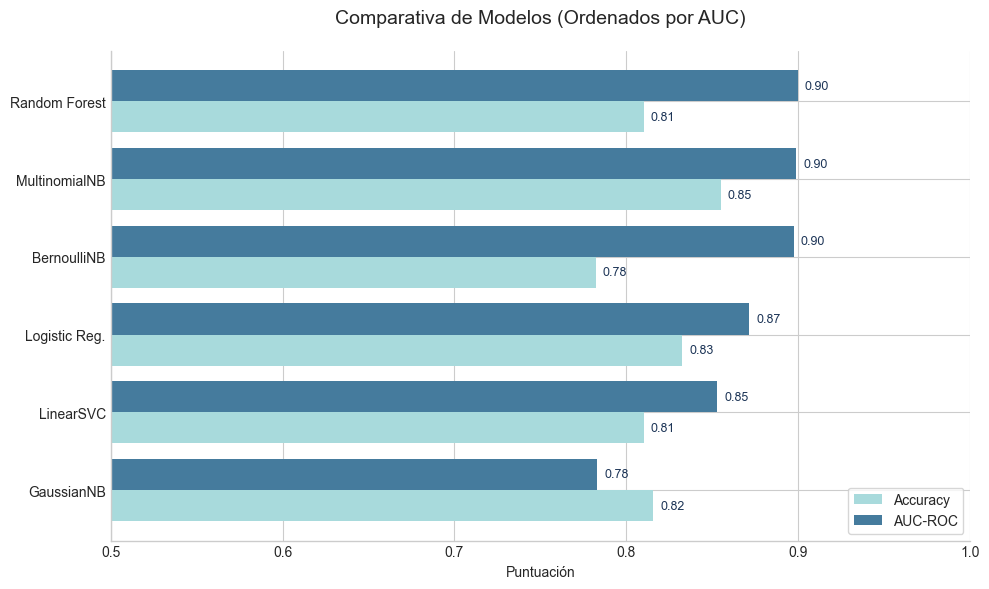

In [149]:
import pandas as pd
import matplotlib.pyplot as plt

# Consolidamos todo en un DataFrame 
resumen_dict = {
    "GaussianNB":      {"Accuracy": accuracy_score(y_test, y_pred_gnb), "AUC-ROC": roc_auc_score(y_test, y_prob_gnb)},
    "MultinomialNB":   {"Accuracy": accuracy_score(y_test, y_pred_mnb), "AUC-ROC": roc_auc_score(y_test, y_prob_mnb)},
    "BernoulliNB":     {"Accuracy": accuracy_score(y_test, y_pred_bnb), "AUC-ROC": roc_auc_score(y_test, y_prob_bnb)},
    "Random Forest":   {"Accuracy": acc_rf, "AUC-ROC": auc_rf},
    "Logistic Reg.":   {"Accuracy": accuracy_score(y_test, y_pred_lr), "AUC-ROC": roc_auc_score(y_test, y_prob_lr)},
    "LinearSVC":       {"Accuracy": accuracy_score(y_test, y_pred_svc), "AUC-ROC": roc_auc_score(y_test, y_score_svc)}
}

df_final = pd.DataFrame(resumen_dict).T.sort_values("AUC-ROC", ascending=True)

# Gráfico simplificado
plt.style.use('seaborn-v0_8-whitegrid') 
ax = df_final.plot(kind='barh', figsize=(10, 6), color=['#A8DADC', '#457B9D'], width=0.8)

# Estética mínima
plt.title("Comparativa de Modelos (Ordenados por AUC)", fontsize=14, pad=20)
plt.xlabel("Puntuación")
plt.xlim(0.5, 1.0) 
plt.legend(loc='lower right', frameon=True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Añadir los valores al final de la barra solo si son necesarios
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}', 
                (p.get_width(), p.get_y() + p.get_height() / 2),
                xytext=(5, 0), textcoords='offset points', 
                va='center', fontsize=9, color='#1D3557')

plt.tight_layout()
plt.show()

In [150]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Recolección de datos para el reporte final

summary = {
    "GaussianNB": {
        "acc": accuracy_score(y_test, y_pred_gnb), 
        "auc": roc_auc_score(y_test, y_prob_gnb)
    },
    "MultinomialNB": {
        "acc": accuracy_score(y_test, y_pred_mnb), 
        "auc": roc_auc_score(y_test, y_prob_mnb)
    },
    "BernoulliNB": {
        "acc": accuracy_score(y_test, y_pred_bnb), 
        "auc": roc_auc_score(y_test, y_prob_bnb)
    },
    "Random Forest": {
        "acc": acc_rf, 
        "auc": auc_rf
    },
    "Logistic Regression": {
        "acc": accuracy_score(y_test, y_pred_lr), 
        "auc": roc_auc_score(y_test, y_prob_lr)
    },
    "LinearSVC": {
        "acc": accuracy_score(y_test, y_pred_svc), 
        "auc": roc_auc_score(y_test, y_score_svc)
    }
}

# Calculamos el mejor AUC global
best_auc_global = max(v["auc"] for v in summary.values())

print(f"{'REPORTE COMPARATIVO FINAL':^65}")

print(f"{'Modelo':<22} {'Accuracy':>12} {'AUC-ROC':>12}")

# Iteramos sobre el resumen
for name, v in summary.items():
       
    # Imprimimos la fila con formato
    print(f"{name:<22} {v['acc']:>12.4f} {v['auc']:>12.4f} {marker}")

print("Nota: El ganador se define por el valor de AUC-ROC.")


                    REPORTE COMPARATIVO FINAL                    
Modelo                     Accuracy      AUC-ROC
GaussianNB                   0.8156       0.7832 
MultinomialNB                0.8547       0.8987 
BernoulliNB                  0.7821       0.8973 
Random Forest                0.8101       0.8998 
Logistic Regression          0.8324       0.8714 
LinearSVC                    0.8101       0.8529 
Nota: El ganador se define por el valor de AUC-ROC.


Conclusión
El objetivo de este ejercicio era clasificar reseñas de aplicaciones en positivas o negativas a partir únicamente del contenido textual. Tras aplicar el pipeline completo —limpieza, vectorización y entrenamiento de varios modelos— estos son los principales aprendizajes:

Sobre el preprocesamiento
La variable package_name fue descartada correctamente, ya que la polaridad de una reseña depende exclusivamente de su contenido. La transformación con CountVectorizer con eliminación de stopwords produjo un vocabulario de 3.272 palabras, que sirvió como base numérica para todos los modelos.

Sobre Naive Bayes
De las tres implementaciones, MultinomialNB resultó la más adecuada tanto teórica como empíricamente. Teóricamente, porque CountVectorizer genera conteos de palabras (valores enteros no negativos), que es exactamente el tipo de dato que MultinomialNB modela. Empíricamente, obtuvo la mejor accuracy (0.8547) y un AUC-ROC de 0.8987, frente a GaussianNB (0.7832) y BernoulliNB (0.8973). GaussianNB asume distribución normal continua, lo que no aplica a este contexto, y BernoulliNB, aunque trabaja bien con texto, pierde información al ignorar la frecuencia de cada término.

Sobre la optimización con Random Forest
El Random Forest (175 árboles) alcanzó un AUC-ROC de 0.8994, mejorando ligeramente a MultinomialNB. Esto se explica porque los árboles pueden capturar interacciones entre palabras que Naive Bayes no modela, al asumir independencia condicional entre features. Sin embargo, la mejora es marginal (~0.0007 en AUC), lo que indica que en este dataset el texto es suficientemente bien capturado con un modelo lineal simple.

Sobre las alternativas
Logistic Regression y LinearSVC son candidatos naturales para superar a Naive Bayes en clasificación de texto, ya que no asumen independencia entre palabras y optimizan directamente el margen de separación. Sin embargo, en este caso ninguno superó al conjunto MultinomialNB / Random Forest: Logistic Regression obtuvo un AUC de 0.8714 y LinearSVC de 0.8529. Esto sugiere que el dataset, siendo relativamente pequeño (891 muestras) y con vocabulario limitado, favorece al enfoque probabilístico bayesiano sobre los modelos de margen.

Modelo final seleccionado
Random Forest con AUC-ROC = 0.8994 y accuracy = 0.8101, guardado junto al vectorizador para su reutilización en inferencia.